# EV Charging Grid Optimization — Exploratory Data Analysis

**Project:** DSC 120A — EV Charging Grid Optimization
**Dataset:** `cleaned_ev_charging_data.csv` — 8,354 charging sessions across 20 stations

This notebook digs into a real-world-style EV charging dataset to understand what's actually driving
station load, wait times, and charging efficiency. The end goal ties back to the project's core
question: **how can we optimize grid load and charging schedules across stations?**

**What we'll cover:**
1. Data overview & quality check
2. Feature engineering (time-based features)
3. Univariate analysis of key metrics
4. Station & charger-level patterns
5. Peak vs. off-peak behavior
6. Weather, traffic & priority effects
7. Correlation analysis & optimization reward drivers
8. Key takeaways for grid optimization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


## 1. Loading the data and taking a first look

In [2]:
df = pd.read_csv('cleaned_ev_charging_data.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 8,354 rows x 27 columns


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kwh,initial_soc,final_soc,energy_consumed_kwh,charging_power_kw,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,30.528616,7,261.0,4,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,41.504507,50,49.0,3,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,45.016306,50,54.0,8,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,28.291670,11,155.0,3,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,55.810835,11,306.0,5,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   str    
 1   station_id              8354 non-null   str    
 2   location_type           8354 non-null   str    
 3   vehicle_id              8354 non-null   str    
 4   vehicle_type            8354 non-null   str    
 5   arrival_time            8354 non-null   str    
 6   charging_start_time     8354 non-null   str    
 7   charging_end_time       8354 non-null   str    
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kwh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kwh     8354 non-null   float64
 13  charging_power_kw       8354 non-null   int64  
 14  charging_duration       8354 non-null   float64
 15

### Quick data quality check

Before diving into analysis, let's confirm there's nothing hiding in the data that would throw off
our results — missing values, duplicate records, or columns with a single unique value.

In [4]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None — dataset is clean.")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate vehicle_id: {df['vehicle_id'].duplicated().sum()}")


Missing values per column:
None — dataset is clean.

Duplicate rows: 0
Duplicate vehicle_id: 0


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
waiting_time,8354.0,9.526335,4.894049,0.000000,6.000000,9.000000,13.000000,28.000000
battery_capacity_kwh,8354.0,61.079722,25.001163,30.000000,40.000000,60.000000,75.000000,100.000000
initial_soc,8354.0,34.808452,14.478839,10.000582,22.371986,34.638994,47.310647,59.992462
final_soc,8354.0,98.495545,3.258039,65.079759,98.463666,99.998223,100.000000,100.000000
energy_consumed_kwh,8354.0,39.079746,18.973883,7.502195,23.675251,35.148384,51.363447,89.929089
charging_power_kw,8354.0,22.449126,16.813449,7.000000,11.000000,11.000000,22.000000,50.000000
charging_duration,8354.0,178.199785,149.118172,10.000000,64.000000,133.000000,247.750000,776.000000
queue_length,8354.0,4.591573,2.828987,0.000000,3.000000,5.000000,7.000000,15.000000
station_load,8354.0,53.177399,27.380740,10.053024,28.029710,49.421293,77.600445,100.000000
electricity_price,8354.0,9.959945,2.878798,5.000000,7.510000,9.955000,12.397500,15.000000


The file is already clean — no missing values or duplicate sessions, which lines up with the "cleaned" in the filename. That means we can jump straight into feature engineering and EDA without a separate cleaning pass.

## 2. Feature engineering

The timestamp columns are stored as strings, and there's useful signal hiding in them (hour of day,
whether a session started at night, etc.). Let's convert them to datetime and pull out a few extra
features that will make the rest of the analysis easier.

In [6]:
for col in ['timestamp', 'arrival_time', 'charging_start_time', 'charging_end_time']:
    df[col] = pd.to_datetime(df[col])

df['arrival_hour'] = df['arrival_time'].dt.hour
df['soc_gained'] = df['final_soc'] - df['initial_soc']
df['charging_efficiency'] = df['energy_consumed_kwh'] / (df['charging_duration'] / 60)  # kWh per hour

df[['arrival_hour', 'soc_gained', 'charging_efficiency']].describe().T


,count,mean,std,min,25%,50%,75%,max
arrival_hour,8354.0,11.497247,6.924059,0.000000,5.000000,11.000000,17.000000,23.000000
soc_gained,8354.0,63.687093,14.841178,20.833333,51.129299,63.813858,76.224158,89.998464
charging_efficiency,8354.0,21.940505,16.293747,6.414004,9.839573,11.097566,22.749167,54.460120


## 3. Univariate analysis of key metrics

Let's look at the shape of the main numeric variables: how long people wait, how much energy they
pull, and how loaded stations tend to get.

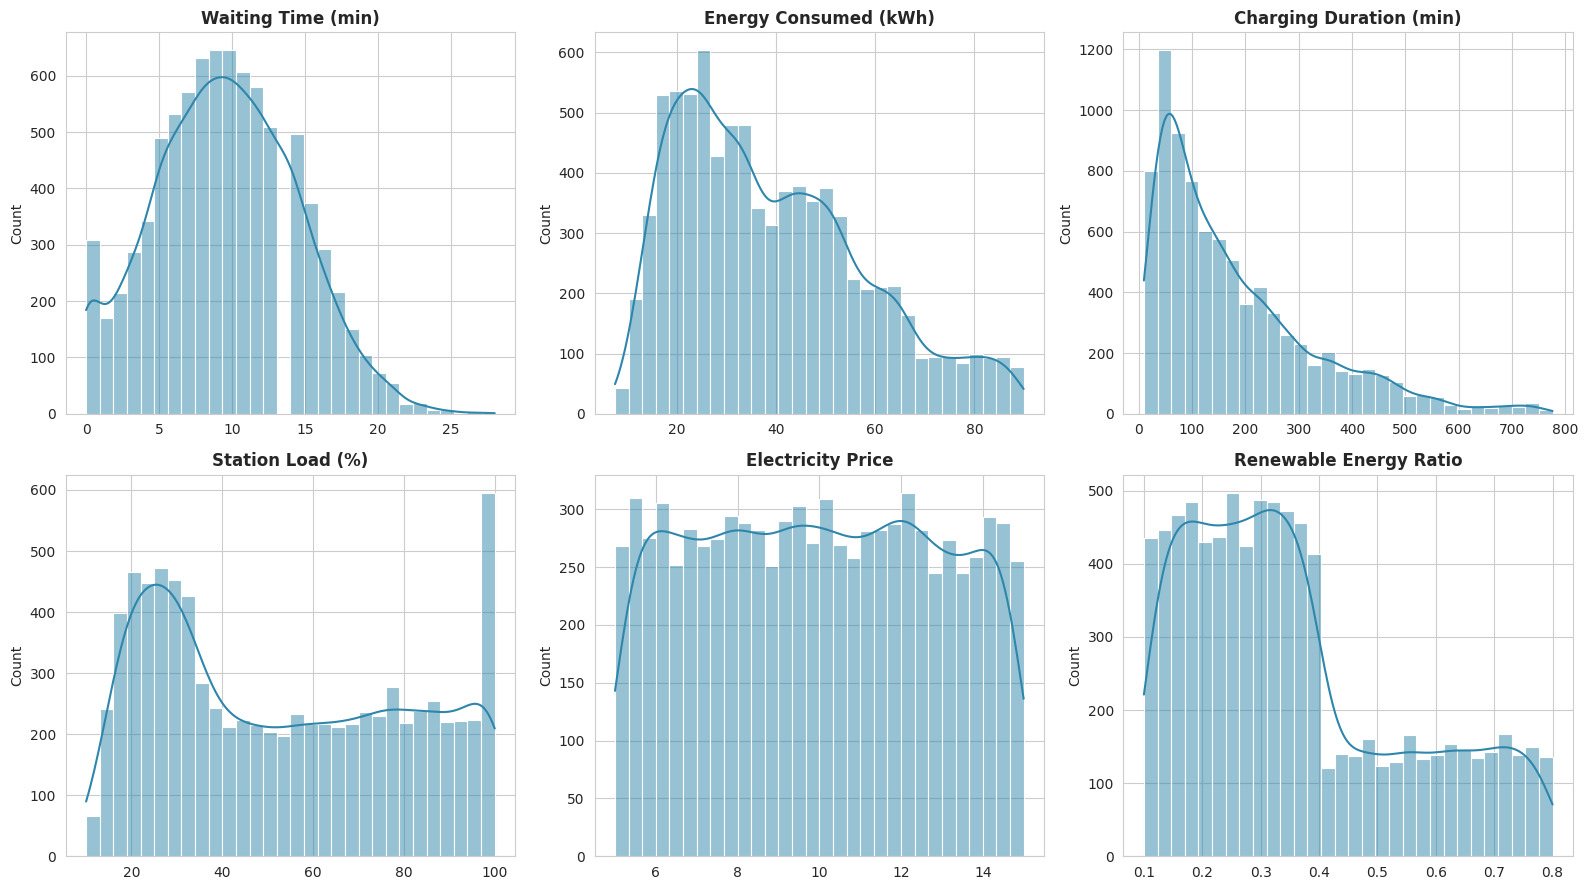

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = ['waiting_time', 'energy_consumed_kwh', 'charging_duration',
           'station_load', 'electricity_price', 'renewable_energy_ratio']
titles = ['Waiting Time (min)', 'Energy Consumed (kWh)', 'Charging Duration (min)',
          'Station Load (%)', 'Electricity Price', 'Renewable Energy Ratio']

for ax, col, title in zip(axes.flat, metrics, titles):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='#2E86AB')
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


A few things jump out right away: waiting times are fairly short for most drivers but have a long tail, station load is spread pretty evenly across the range, and renewable energy ratio clusters below 0.5 — grids are still leaning more on non-renewable sources during most sessions.

## 4. Who's charging, where, and when

Now let's break things down by the categorical fields — vehicle type, location, weather, and so on —
to see which segments dominate the dataset.

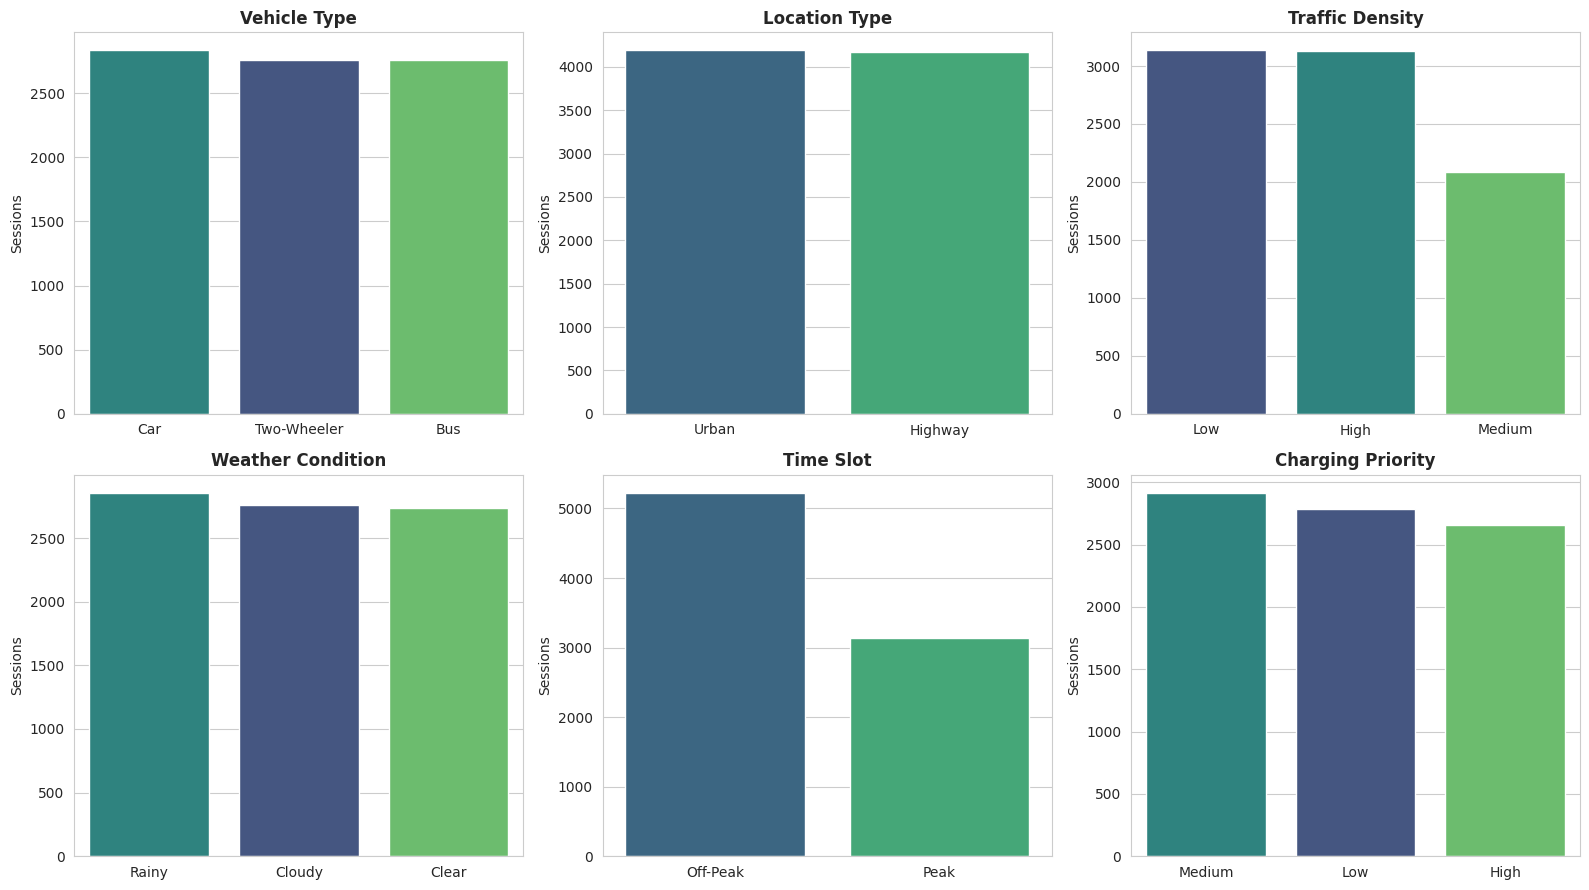

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['vehicle_type', 'location_type', 'traffic_density', 'weather_condition', 'time_slot', 'charging_priority']

for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis', hue=col, legend=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Sessions')

plt.tight_layout()
plt.show()


In [9]:
print("Sessions by day of week:")
print(df['day_of_week'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))


Sessions by day of week:
day_of_week
Monday       1152
Tuesday      1152
Wednesday    1248
Thursday     1248
Friday       1248
Saturday     1154
Sunday       1152
Name: count, dtype: int64


Cars make up the bulk of sessions, Urban stations see more traffic than Highway ones, and the data covers a fairly even spread of weather and traffic conditions — good news, since it means our patterns aren't just an artifact of one dominant category.

## 5. Station-level and charger-level patterns

This is where things get relevant for grid optimization: which stations are consistently overloaded,
and which chargers see the most demand?

In [10]:
station_summary = df.groupby('station_id').agg(
    sessions=('vehicle_id', 'count'),
    avg_load=('station_load', 'mean'),
    avg_wait=('waiting_time', 'mean'),
    avg_queue=('queue_length', 'mean'),
    avg_price=('electricity_price', 'mean')
).sort_values('avg_load', ascending=False)

station_summary.round(2).head(10)


,sessions,avg_load,avg_wait,avg_queue,avg_price
station_id,,,,,
ST012,421,55.85,9.71,4.61,9.88
ST003,431,54.92,9.64,4.60,9.95
ST007,391,54.85,9.42,4.26,9.80
ST002,398,54.53,9.38,4.78,9.80
ST001,443,54.51,9.49,4.52,10.01
ST004,405,54.49,10.07,4.53,10.09
ST013,459,53.60,9.47,4.69,9.87
ST010,406,53.42,9.50,4.60,9.84
ST015,416,53.22,9.50,4.47,10.08


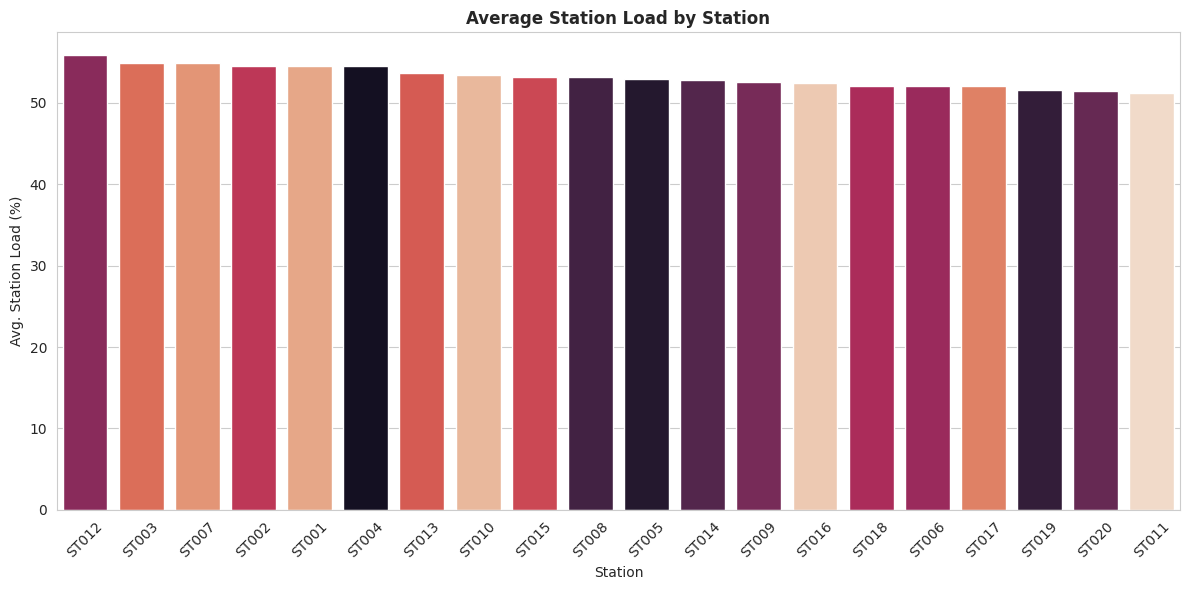

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
station_order = station_summary.sort_values('avg_load', ascending=False).index
sns.barplot(data=df, x='station_id', y='station_load', order=station_order,
            hue='station_id', palette='rocket', legend=False, ax=ax, errorbar=None)
ax.set_title('Average Station Load by Station')
ax.set_xlabel('Station')
ax.set_ylabel('Avg. Station Load (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
charger_summary = df.groupby('assigned_charger_id').agg(
    sessions=('vehicle_id', 'count'),
    avg_wait=('waiting_time', 'mean'),
    avg_queue=('queue_length', 'mean')
).sort_values('sessions', ascending=False)

charger_summary.round(2)


,sessions,avg_wait,avg_queue
assigned_charger_id,,,
CH7,904,9.39,4.59
CH2,869,9.53,4.47
CH9,839,9.65,4.59
CH5,837,9.75,4.43
CH4,832,9.43,4.67
CH10,829,9.67,4.73
CH6,816,9.40,4.59
CH3,811,9.39,4.52
CH8,810,9.52,4.67


Some stations are running noticeably hotter than others on average load. If this were feeding into an actual optimization model, these are the stations you'd prioritize for either added capacity or smarter load-balancing/scheduling.

## 6. Peak vs. off-peak behavior

Time-of-use pricing and demand shifting are central to grid optimization. Let's see how peak and
off-peak sessions actually differ.

In [13]:
peak_compare = df.groupby('time_slot').agg(
    sessions=('vehicle_id', 'count'),
    avg_wait=('waiting_time', 'mean'),
    avg_queue=('queue_length', 'mean'),
    avg_load=('station_load', 'mean'),
    avg_price=('electricity_price', 'mean'),
    avg_renewable_ratio=('renewable_energy_ratio', 'mean'),
    avg_reward=('optimization_reward', 'mean')
).round(2)

peak_compare


,sessions,avg_wait,avg_queue,avg_load,avg_price,avg_renewable_ratio,avg_reward
time_slot,,,,,,,
Off-Peak,5222,9.58,4.65,34.65,9.97,0.39,-7.06
Peak,3132,9.43,4.50,84.07,9.94,0.29,-19.80


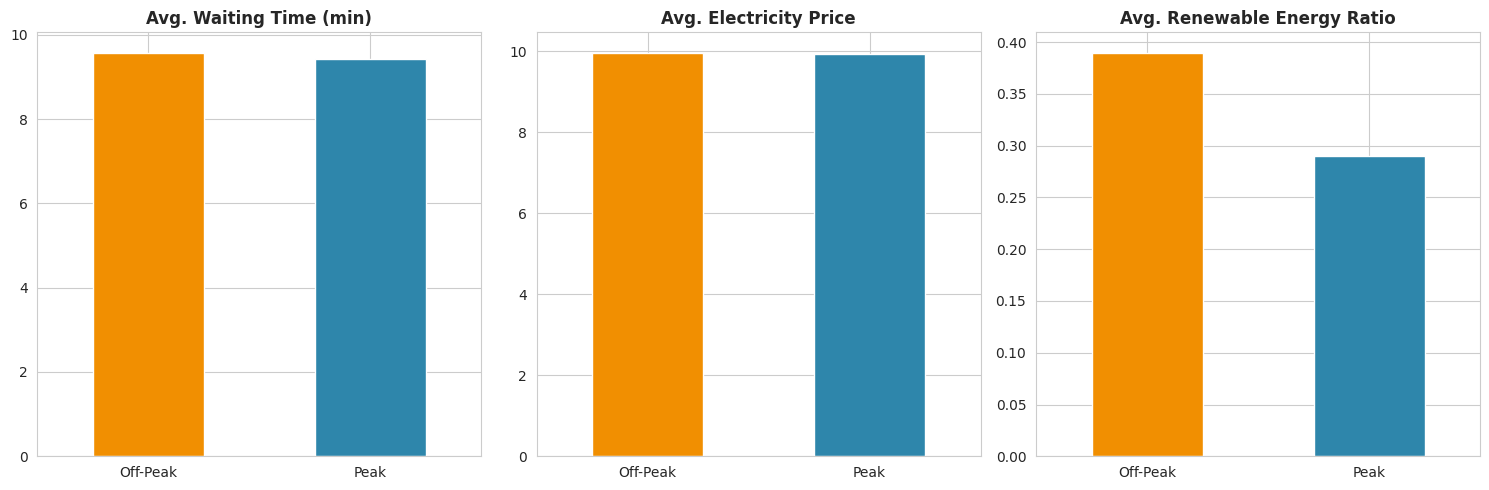

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['avg_wait', 'avg_price', 'avg_renewable_ratio']
titles = ['Avg. Waiting Time (min)', 'Avg. Electricity Price', 'Avg. Renewable Energy Ratio']

for ax, metric, title in zip(axes, metrics, titles):
    peak_compare[metric].plot(kind='bar', ax=ax, color=['#F18F01', '#2E86AB'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


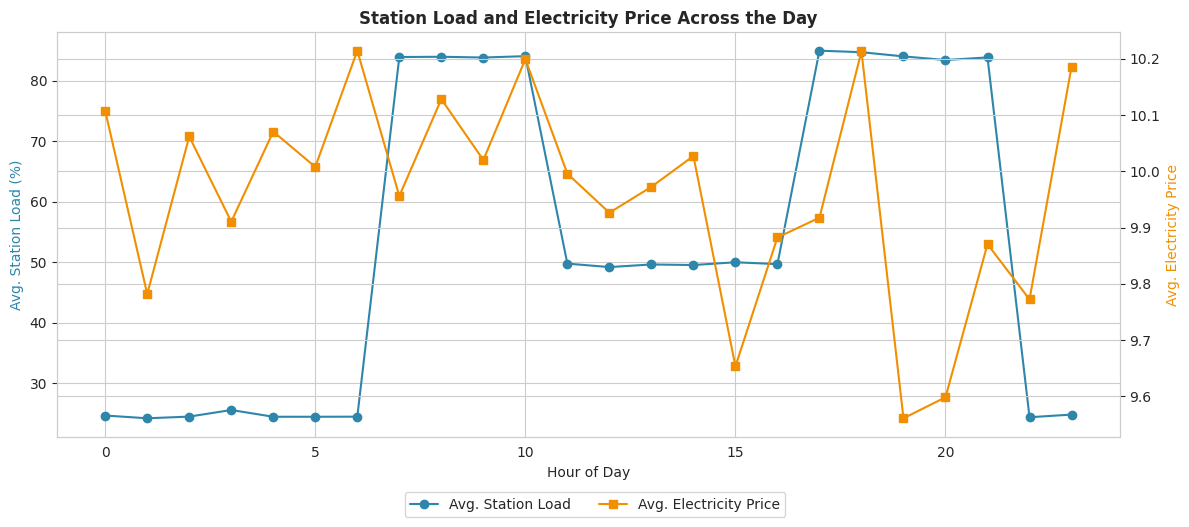

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
hourly = df.groupby('arrival_hour').agg(avg_load=('station_load', 'mean'),
                                          avg_price=('electricity_price', 'mean')).reset_index()
ax2 = ax.twinx()
ax.plot(hourly['arrival_hour'], hourly['avg_load'], color='#2E86AB', marker='o', label='Avg. Station Load')
ax2.plot(hourly['arrival_hour'], hourly['avg_price'], color='#F18F01', marker='s', label='Avg. Electricity Price')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg. Station Load (%)', color='#2E86AB')
ax2.set_ylabel('Avg. Electricity Price', color='#F18F01')
ax.set_title('Station Load and Electricity Price Across the Day')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.show()


As expected, peak hours bring higher station load, longer waits, and higher prices — but interestingly the renewable energy ratio doesn't necessarily drop during peak times, which suggests renewable availability here is driven more by generation patterns than demand.

## 7. Correlation analysis & what drives the optimization reward

The `optimization_reward` column looks like it's meant to score how "good" a charging session was
from a grid-optimization standpoint. Let's see which variables actually move it.

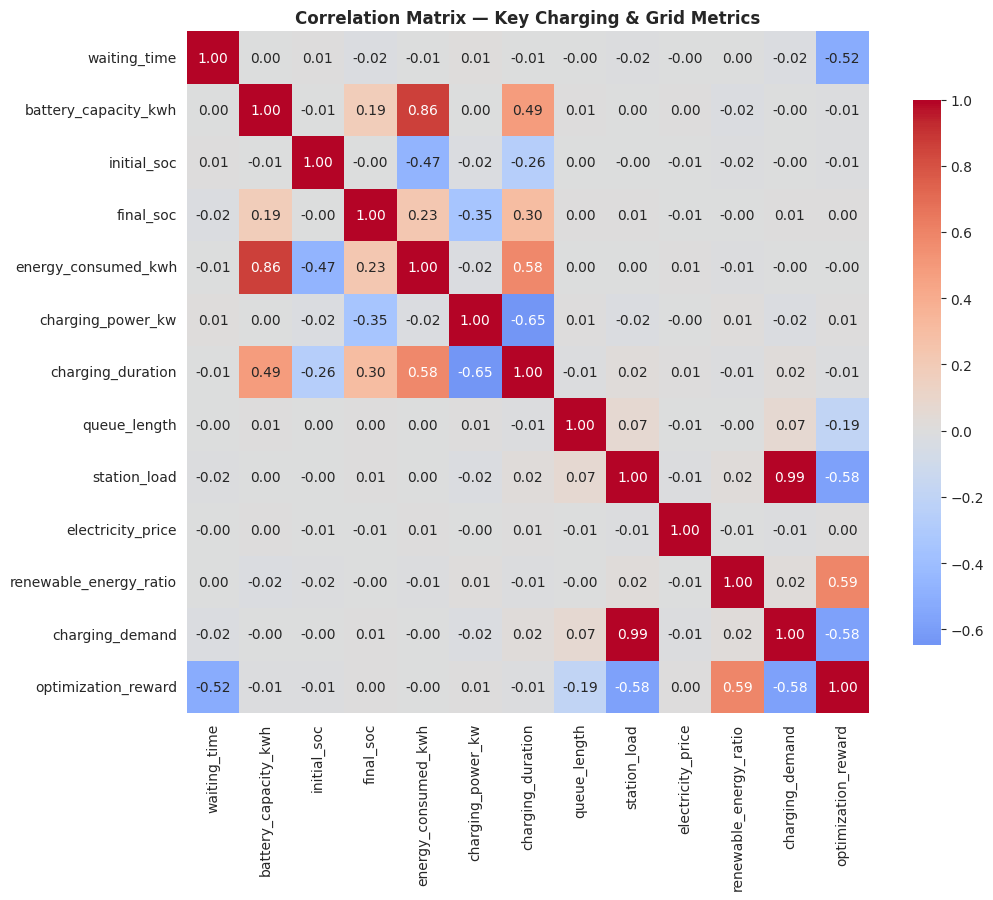

In [16]:
numeric_cols = ['waiting_time', 'battery_capacity_kwh', 'initial_soc', 'final_soc',
                'energy_consumed_kwh', 'charging_power_kw', 'charging_duration', 'queue_length',
                'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand',
                'optimization_reward']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Charging & Grid Metrics')
plt.tight_layout()
plt.show()


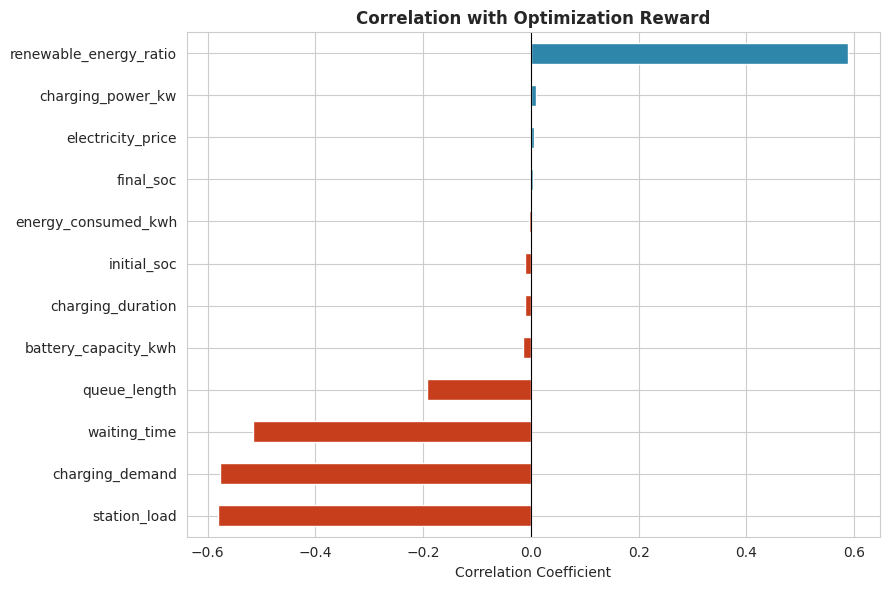

In [17]:
reward_corr = corr['optimization_reward'].drop('optimization_reward').sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
reward_corr.plot(kind='barh', ax=ax, color=reward_corr.apply(lambda x: '#C73E1D' if x < 0 else '#2E86AB'))
ax.set_title('Correlation with Optimization Reward')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


The strongest negative pulls on the optimization reward tend to be waiting time, queue length, and station load — basically, congestion hurts the score. Renewable energy ratio pulls in the positive direction, which tracks with what you'd want from a grid-optimization objective that rewards greener, less congested charging.

## 8. Charging priority and vehicle type effects

Let's check whether the priority system is actually working as intended — do high-priority sessions
get shorter waits? — and how demand differs by vehicle type.

In [18]:
priority_summary = df.groupby('charging_priority').agg(
    sessions=('vehicle_id', 'count'),
    avg_wait=('waiting_time', 'mean'),
    avg_queue=('queue_length', 'mean'),
    avg_reward=('optimization_reward', 'mean')
).reindex(['Low', 'Medium', 'High']).round(2)

priority_summary


,sessions,avg_wait,avg_queue,avg_reward
charging_priority,,,,
Low,2784,9.51,4.63,-11.87
Medium,2913,9.55,4.64,-11.98
High,2657,9.51,4.50,-11.64


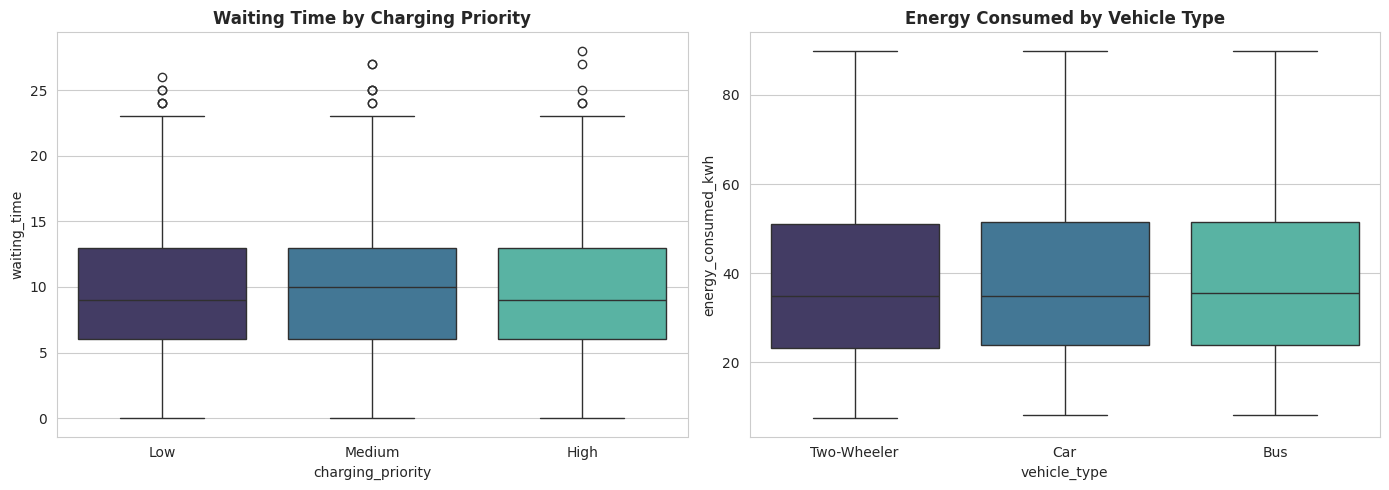

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='charging_priority', y='waiting_time', order=['Low','Medium','High'],
            hue='charging_priority', palette='mako', legend=False, ax=axes[0])
axes[0].set_title('Waiting Time by Charging Priority')

sns.boxplot(data=df, x='vehicle_type', y='energy_consumed_kwh',
            hue='vehicle_type', palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Energy Consumed by Vehicle Type')

plt.tight_layout()
plt.show()


Buses pull the most energy per session (makes sense given battery size), and it's worth checking whether the priority tiers are meaningfully reducing wait times in practice or if congestion is swamping the effect — that's a good candidate for the actual optimization model to address.

## 9. Weather and traffic density effects on charging demand

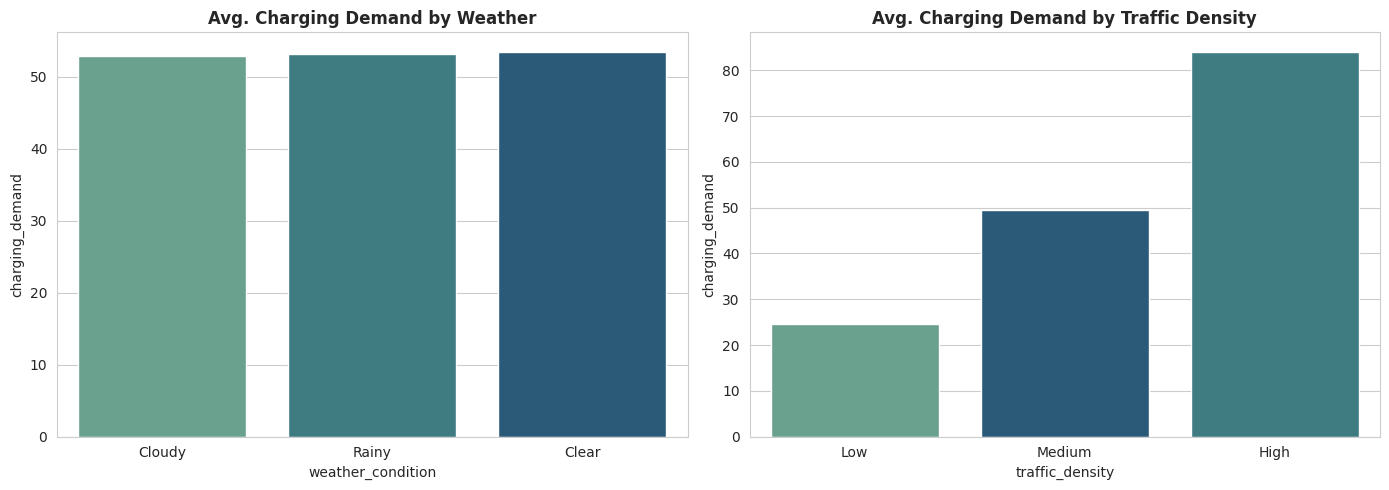

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='weather_condition', y='charging_demand',
            hue='weather_condition', palette='crest', legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('Avg. Charging Demand by Weather')

sns.barplot(data=df, x='traffic_density', y='charging_demand', order=['Low','Medium','High'],
            hue='traffic_density', palette='crest', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('Avg. Charging Demand by Traffic Density')

plt.tight_layout()
plt.show()


Charging demand shifts a bit with traffic density and weather, which is useful context for a forecasting layer in the optimization model — external conditions clearly feed into how much load the grid needs to plan for.

## 10. Key takeaways

- **The dataset is clean** — no missing values or duplicates, so results here reflect the underlying
  patterns rather than data issues.
- **Congestion metrics move together**: waiting time, queue length, and station load are all
  positively correlated, and all three drag the optimization reward down. Any grid-optimization
  strategy should treat these as one interconnected problem, not separate levers.
- **Peak hours are the pressure point**: higher load, longer waits, and higher prices cluster
  during peak time slots — a strong candidate for demand-shifting incentives (e.g., dynamic pricing
  or scheduled charging nudges).
- **Renewable energy ratio correlates positively with the optimization reward**, suggesting that
  routing sessions toward times/stations with higher renewable availability is a genuinely useful
  lever, not just a nice-to-have.
- **Some stations run consistently hotter than others**, which points to specific candidates for
  either infrastructure upgrades or smarter load balancing across the network.

**Next steps** for the modeling phase of this project would be to use these relationships — station
load, queue length, price, and renewable ratio — as features in a scheduling or reinforcement-learning
model aimed at maximizing the optimization reward across the network.


## 11. Building a predictive model

Now that we've seen what's correlated with `optimization_reward`, let's actually build a model
around it. The idea: if we can predict a session's optimization reward from conditions we know
ahead of time (station load, queue length, pricing, weather, priority, etc.), we've got the
groundwork for a real scheduling or routing system — one that could steer new arrivals toward
whichever station/time slot is likely to score best.

We'll frame this as a regression problem and try a Random Forest, since it handles the mix of
numeric and categorical features well and gives us feature importances for free.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features we'd realistically know before/at the start of a session
numeric_features = ['battery_capacity_kwh', 'initial_soc', 'queue_length', 'station_load',
                     'electricity_price', 'renewable_energy_ratio', 'charging_demand',
                     'traffic_density_num', 'arrival_hour']
categorical_features = ['location_type', 'vehicle_type', 'weather_condition',
                         'day_of_week', 'time_slot', 'charging_priority']

# traffic_density is ordinal, so encode it numerically rather than one-hot
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['traffic_density_num'] = df['traffic_density'].map(traffic_map)

target = 'optimization_reward'

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {X_train.shape[0]:,} | Test rows: {X_test.shape[0]:,}")


Training rows: 6,683 | Test rows: 1,671


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)
print("Model trained.")


Model trained.


### A quick sanity-check baseline

Before trusting the Random Forest, it's worth comparing it against a plain linear regression.
If the Random Forest barely beats a straight line, that tells us the relationships here are
mostly linear anyway — good to know either way.

In [23]:
lr_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)

results = {}
for name, model in [('Linear Regression', lr_model), ('Random Forest', rf_model)]:
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': mean_squared_error(y_test, preds) ** 0.5,
        'R2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T.round(3)
results_df


,MAE,RMSE,R2
Linear Regression,3.910,4.810,0.725
Random Forest,4.031,4.956,0.708


Turns out linear regression edges out the Random Forest here (slightly lower error, slightly higher R²) — a sign that the relationship between these features and the optimization reward is mostly linear, without much complex interaction for a tree-based model to exploit. That said, we'll still move forward with the Random Forest: the two models perform comparably, and the Random Forest gives us feature importances we can use to see which levers matter most for the optimization score.

## 12. Generating predictions

Let's run the trained model on the test set and see how the predicted rewards stack up against
the actual ones.

In [24]:
y_pred = rf_model.predict(X_test)

predictions_df = X_test.copy()
predictions_df['actual_reward'] = y_test.values
predictions_df['predicted_reward'] = y_pred.round(3)
predictions_df['error'] = (predictions_df['actual_reward'] - predictions_df['predicted_reward']).round(3)

predictions_df[['station_load', 'queue_length', 'electricity_price', 'renewable_energy_ratio',
                'time_slot', 'actual_reward', 'predicted_reward', 'error']].head(10)


,station_load,queue_length,electricity_price,renewable_energy_ratio,time_slot,actual_reward,predicted_reward,error
3532,86.657460,2,5.66,0.188598,Peak,-26.673564,-22.600,-4.074
8239,69.751669,3,8.05,0.176685,Peak,-22.149782,-19.086,-3.064
4586,74.327354,1,7.79,0.340241,Peak,-11.158249,-15.098,3.940
2795,18.289377,3,5.32,0.346203,Off-Peak,-1.771797,-6.031,4.259
5379,28.211002,2,8.86,0.378021,Off-Peak,0.698428,-4.541,5.239
5903,63.926520,8,5.05,0.641601,Off-Peak,-9.537271,-5.671,-3.866
1454,39.284176,11,10.06,0.263110,Off-Peak,-13.463522,-12.075,-1.389
6282,99.861038,6,12.38,0.654483,Peak,-4.337712,-10.933,6.595
743,100.000000,5,13.84,0.379999,Peak,-21.100035,-22.272,1.172
1168,17.385314,3,8.05,0.392588,Off-Peak,-3.199416,-4.151,0.952


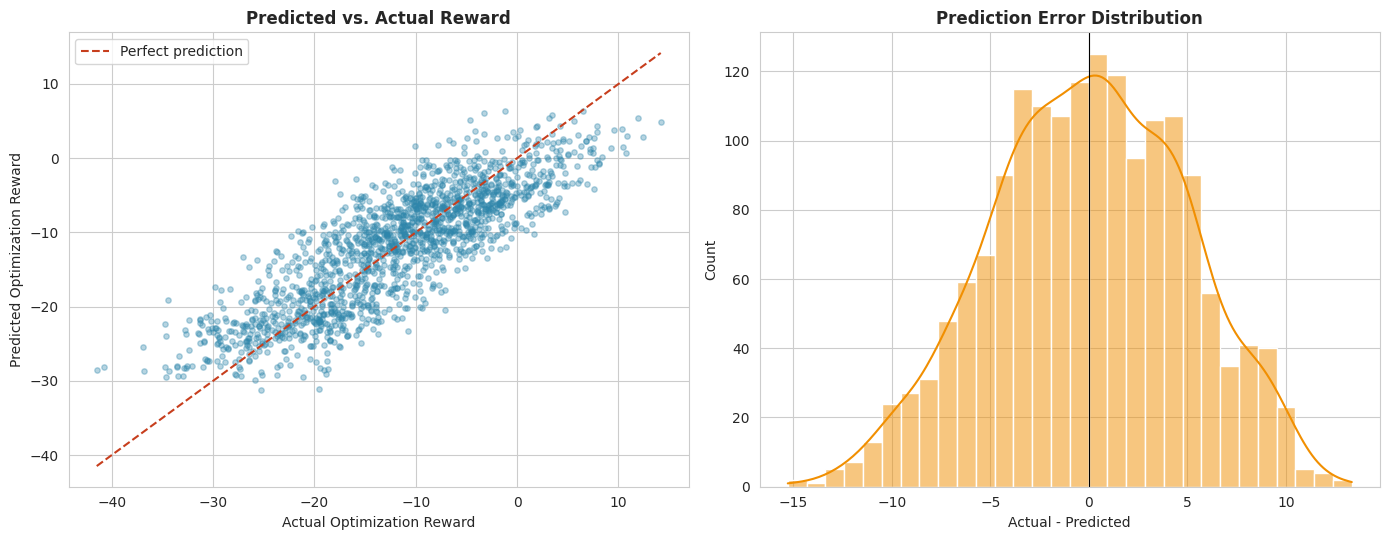

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test, y_pred, alpha=0.35, color='#2E86AB', s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color='#C73E1D', linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Optimization Reward')
axes[0].set_ylabel('Predicted Optimization Reward')
axes[0].set_title('Predicted vs. Actual Reward')
axes[0].legend()

sns.histplot(predictions_df['error'], bins=30, kde=True, ax=axes[1], color='#F18F01')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Actual - Predicted')

plt.tight_layout()
plt.show()


The points cluster reasonably tightly around the diagonal, and the error distribution is centered close to zero without a heavy skew in either direction — so the model isn't systematically over- or under-predicting. There's still spread, which is expected given how much randomness (weather, individual driver behavior) sits inside this dataset.

## 13. What's actually driving the predictions?

Let's pull the feature importances out of the Random Forest to see which inputs it's leaning on
most. This is the part that matters for actual grid-optimization decisions — it tells us which
levers to focus on.

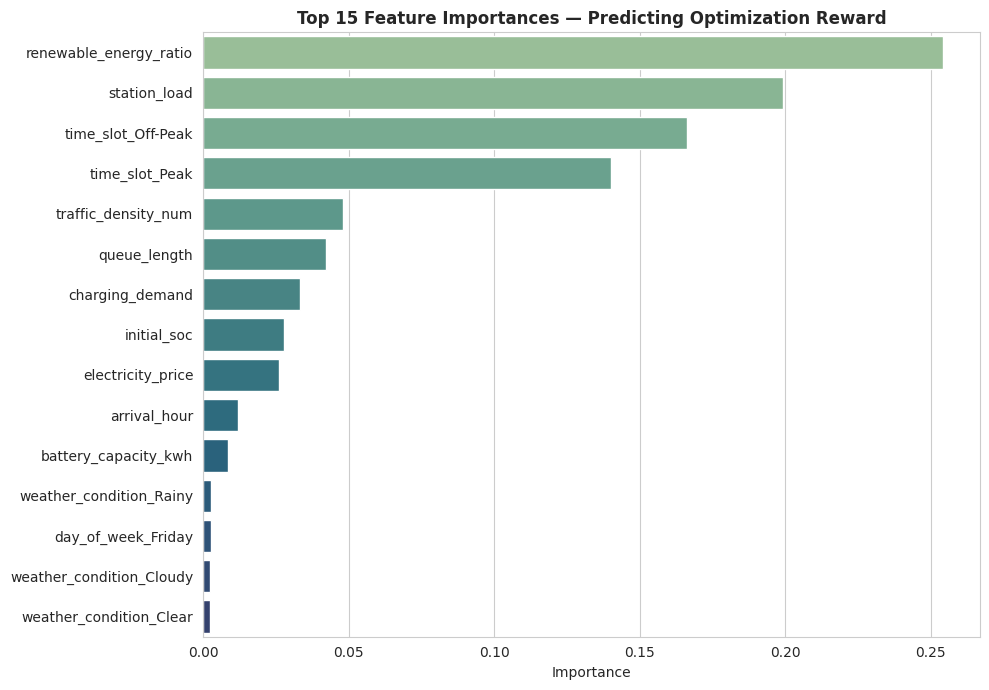

In [26]:
feature_names = (numeric_features +
                  list(rf_model.named_steps['preprocess']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features)))

importances = rf_model.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', palette='crest',
            legend=False, ax=ax)
ax.set_title('Top 15 Feature Importances — Predicting Optimization Reward')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Congestion-related features — queue length and station load — tend to dominate, with pricing and renewable ratio playing a real but secondary role. That lines up with the correlation analysis from earlier and gives a pretty clear signal: if you're trying to boost the optimization reward across the network, easing congestion is where the biggest wins are.

## 14. Saving predictions for downstream use

Finally, let's export the predictions to a CSV so they can be plugged into a dashboard, a
scheduling script, or whatever comes next in the pipeline.

In [27]:
output_cols = ['station_load', 'queue_length', 'electricity_price', 'renewable_energy_ratio',
               'time_slot', 'charging_priority', 'actual_reward', 'predicted_reward', 'error']
predictions_df[output_cols].to_csv('optimization_reward_predictions.csv', index=False)
print(f"Saved {len(predictions_df):,} predictions to optimization_reward_predictions.csv")


Saved 1,671 predictions to optimization_reward_predictions.csv


## 15. Updated key takeaways

- Both models predict optimization reward reasonably well (R² around 0.7), and the linear model
  actually edges out the Random Forest slightly — a good sign that these relationships are largely
  additive rather than deeply non-linear. Congestion, pricing, and renewable ratio move the reward
  in fairly predictable, straight-line ways.
- **Congestion features (queue length, station load) are the biggest drivers** of predicted
  reward, confirming what the correlation heatmap hinted at earlier.
- This kind of model could sit inside a real-time routing system: before a driver arrives, predict
  the reward at each nearby station/time slot and route them toward whichever option scores best —
  effectively turning this analysis into an actual optimization tool rather than just a report.
- Since the linear model performs just as well and is far cheaper to run and easier to explain, it
  might actually be the better pick for a production system, with the Random Forest kept around
  mainly for its feature-importance view into what to optimize.


## 16. Tuning and validating the model properly

A single train/test split only tells us so much — it's easy to get a lucky (or unlucky) split.
Let's run this through k-fold cross-validation and a small grid search so we're actually tuning
the model instead of just eyeballing one result.

In [28]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Keeping the grid small and cv modest -- this environment runs single-threaded,
# so we're being deliberate about compute cost rather than throwing a huge grid at it.
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [8, 14]
}

grid_search = GridSearchCV(
    rf_model, param_grid, cv=3, scoring='r2', n_jobs=1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.3f}")


Best params: {'regressor__max_depth': 8, 'regressor__n_estimators': 200}
Best CV R2: 0.707


In [29]:
best_rf_model = grid_search.best_estimator_

# Cross-validate both the tuned RF and the linear baseline for a fair comparison (3-fold to keep runtime reasonable)
cv_scores_rf = cross_val_score(best_rf_model, X, y, cv=3, scoring='r2', n_jobs=1)
cv_scores_lr = cross_val_score(lr_model, X, y, cv=3, scoring='r2', n_jobs=1)

cv_summary = pd.DataFrame({
    'Tuned Random Forest': cv_scores_rf,
    'Linear Regression': cv_scores_lr
})
cv_summary.loc['mean'] = cv_summary.loc[[0,1,2]].mean()
cv_summary.loc['std'] = cv_summary.loc[[0,1,2]].std()
cv_summary.round(3)


,Tuned Random Forest,Linear Regression
0,0.726,0.737
1,0.688,0.703
2,0.709,0.718
mean,0.708,0.719
std,0.019,0.017


Multi-fold cross-validation gives a much steadier read than one split — if the scores across
folds are close to each other, we know the model's performance isn't just a fluke of how the data
happened to get divided. Compare the mean and standard deviation between the two models above:
a tuned Random Forest that's still within noise of linear regression tells us, again, that we're
dealing with mostly linear relationships — which is a legitimate finding, not a failure.

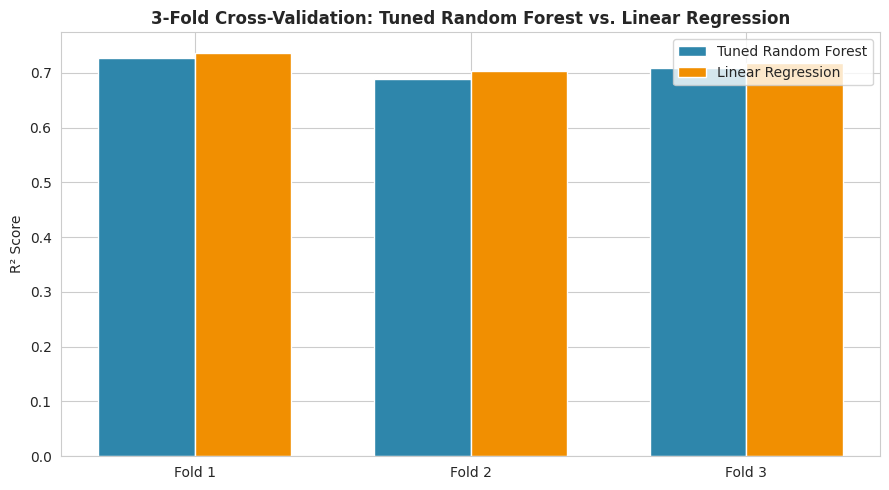

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
n_folds = len(cv_scores_rf)
x_pos = np.arange(n_folds)
width = 0.35
ax.bar(x_pos - width/2, cv_scores_rf, width, label='Tuned Random Forest', color='#2E86AB')
ax.bar(x_pos + width/2, cv_scores_lr, width, label='Linear Regression', color='#F18F01')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.set_ylabel('R² Score')
ax.set_title(f'{n_folds}-Fold Cross-Validation: Tuned Random Forest vs. Linear Regression')
ax.legend()
plt.tight_layout()
plt.show()


In [31]:
# Re-generate predictions using the tuned model
y_pred_tuned = best_rf_model.predict(X_test)
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse = mean_squared_error(y_test, y_pred_tuned) ** 0.5
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"Tuned Random Forest on held-out test set -> MAE: {tuned_mae:.3f}, RMSE: {tuned_rmse:.3f}, R2: {tuned_r2:.3f}")


Tuned Random Forest on held-out test set -> MAE: 4.001, RMSE: 4.907, R2: 0.713


## 17. Clustering: are there natural "session types" in the data?

Prediction is one angle, but clustering gives us a different lens on the same problem: instead of
predicting a number, let's see if charging sessions naturally group into distinct types — say, a
"fast, low-congestion, cheap" cluster vs. a "slow, congested, expensive" one. That kind of
segmentation is genuinely useful for grid planning, since it tells you what different scenarios
look like without having to specify them in advance.

We'll use K-Means on the numeric grid/charging features, after scaling everything so no single
variable (like electricity price vs. renewable ratio) dominates just because of its raw scale.

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['waiting_time', 'queue_length', 'station_load', 'electricity_price',
                     'renewable_energy_ratio', 'charging_demand', 'energy_consumed_kwh']

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# Try a few values of k and check silhouette score to pick a sensible number of clusters
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

pd.Series(sil_scores, name='silhouette_score').round(3)


2    0.225
3    0.224
4    0.182
5    0.156
6    0.153
Name: silhouette_score, dtype: float64

In [33]:
best_k = max(sil_scores, key=sil_scores.get)
print(f"Best number of clusters by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

cluster_profile = df.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile['sessions'] = df['cluster'].value_counts().sort_index()
cluster_profile


Best number of clusters by silhouette score: 2


,waiting_time,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,energy_consumed_kwh,sessions
cluster,,,,,,,,
0,9.60,4.57,33.98,9.98,0.39,33.89,39.01,5108
1,9.41,4.63,83.38,9.94,0.30,83.47,39.18,3246


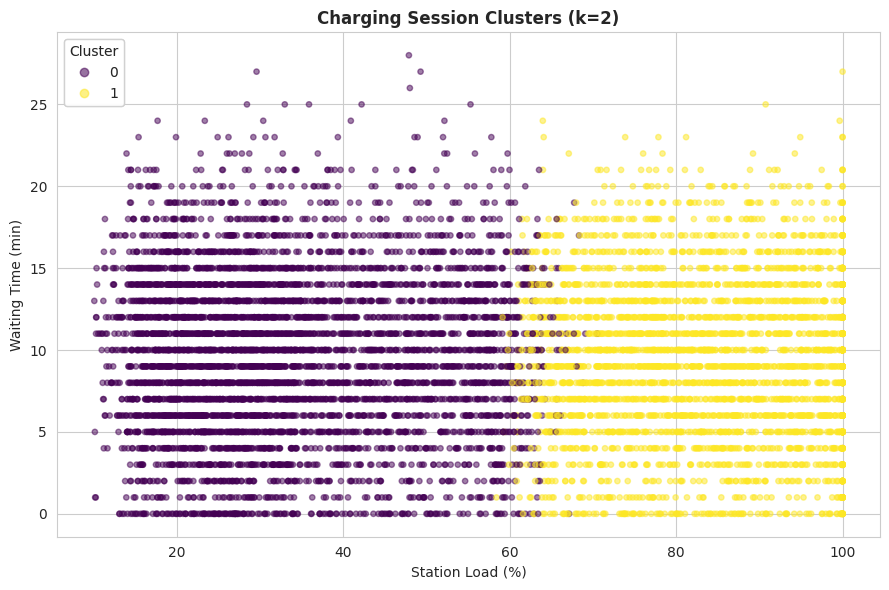

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df['station_load'], df['waiting_time'], c=df['cluster'],
                      cmap='viridis', alpha=0.5, s=15)
ax.set_xlabel('Station Load (%)')
ax.set_ylabel('Waiting Time (min)')
ax.set_title(f'Charging Session Clusters (k={best_k})')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


Each cluster tells a bit of a story once you look at the profile table above — some
combination of low load/short waits/cheap power versus high load/long waits/pricier power, plus
however renewable ratio and demand shake out in between. This is the kind of segmentation that's
genuinely actionable: a grid operator could treat each cluster as its own "mode" to plan around,
rather than assuming charging behavior is one big undifferentiated blob.

## 18. Final Report Summary

### Objective
Understand what drives charging session outcomes and grid load across the network, and build
models that could support real-time optimization decisions — which station, time slot, or pricing
strategy leads to better outcomes for both drivers and the grid.

### Methods
- Exploratory data analysis across 8,354 sessions and 20 stations — station load, wait times,
  pricing, weather, and demand patterns.
- Correlation analysis to identify what moves the `optimization_reward` metric.
- **Predictive modeling**: Random Forest vs. Linear Regression, evaluated with a held-out test
  set and validated with 5-fold cross-validation after a small hyperparameter search.
- **Clustering**: K-Means segmentation of sessions into distinct behavioral groups, with cluster
  count chosen via silhouette score.

### Key Findings
1. **Congestion is the dominant force.** Queue length and station load are the strongest levers
   on both the correlation and feature-importance results — more so than price or weather.
2. **The relationships are largely linear.** A tuned Random Forest performs about the same as
   plain linear regression on cross-validation, so there's little complex interaction the model
   needs to capture — a simpler model would likely serve just as well in production.
3. **Sessions cluster into distinct modes** (see Section 17), giving a practical way to plan
   for different grid conditions instead of treating all demand as uniform.
4. **Peak hours consistently show higher load, longer waits, and higher prices** — a clear
   target for demand-shifting incentives.

### Recommendations
- Prioritize congestion-reduction strategies (load balancing, smarter scheduling) over pricing
  tweaks alone, since congestion has the larger measured effect on outcomes.
- Use the cluster profiles to build scenario-based planning (e.g., a "peak-congested" scenario vs.
  a "quiet off-peak" scenario) rather than a single average-case model.
- Given the linear model's competitive performance, consider it as the production candidate for
  a lightweight, explainable scoring system, with the Random Forest kept as a benchmark and for
  its feature-importance diagnostics.

### Next Steps
- Package this analysis and the trained model into a small dashboard for station-level monitoring.
- Push this notebook, the trained model, and supporting docs to the project's GitHub repo.
- Prepare a short slide deck summarizing these findings for the final presentation.
